# OjoAlerta — Pipeline visual independiente con arquitectura Medallion

Este notebook reorganiza el **pipeline visual** en capas **Bronze → Silver → Gold** y lo mantiene **independiente de la fuente textual**.

> **No se realiza todavía ningún match, join ni correspondencia entre registros visuales y textuales.**

La lógica de capas es:

- **BRONZE:** videos descargados + frames extraídos + manifiestos originales. No se descartan frames por calidad.
- **SILVER:** auditoría de calidad, filtrado lógico de frames, YOLO, CLIP y tabla enriquecida por frame.
- **GOLD:** agregación por segmentos y por video, métricas de evaluación y salidas preparadas para análisis.

## 1. Instalación


In [ ]:

import sys
import subprocess

packages = [
    "ultralytics",
    "transformers",
    "accelerate",
    "pyarrow",
    "opencv-python-headless",
    "pillow",
    "tqdm",
    "matplotlib",
    "scikit-learn",
    "psutil",
    "huggingface_hub",
    "hf_xet",
    "pyspark",
]

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", *packages]
)

print("✓ Dependencias instaladas.")

✓ Dependencias instaladas.


In [ ]:

from pathlib import Path
from datetime import datetime
from collections import defaultdict
from IPython.display import display, Markdown
import json
import os
import time
import math
import shutil

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import psutil

from PIL import Image
from tqdm.auto import tqdm
from ultralytics import YOLO
from transformers import CLIPModel, CLIPProcessor
from huggingface_hub import HfApi, hf_hub_download

# ------------------------------------------------------------------
# MEDALLION
# ------------------------------------------------------------------

LAKEHOUSE = Path("/content/ojoalerta_lakehouse")

BRONZE_DIR = LAKEHOUSE / "bronze" / "visual"
BRONZE_VIDEO_DIR = BRONZE_DIR / "videos"
BRONZE_FRAME_DIR = BRONZE_DIR / "frames"

SILVER_DIR = LAKEHOUSE / "silver" / "visual"
GOLD_DIR = LAKEHOUSE / "gold" / "visual"

CACHE_DIR = Path("/content/ojoalerta_cache")

for folder in [
    BRONZE_VIDEO_DIR,
    BRONZE_FRAME_DIR,
    SILVER_DIR,
    GOLD_DIR,
    CACHE_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# CONFIGURACIÓN DE EXTRACCIÓN
# ------------------------------------------------------------------

TARGET_FRAME_GB = 1.0
TARGET_FRAME_BYTES = int(TARGET_FRAME_GB * 1024**3)

EXTRACT_FPS = 2
JPEG_QUALITY = 82
INFERENCE_STRIDE = 1

# ------------------------------------------------------------------
# CONTROL DE CALIDAD
# ------------------------------------------------------------------


BLUR_THRESHOLD = 80.0              # varianza del Laplaciano
DARK_THRESHOLD = 45.0              # intensidad media 0-255
BRIGHT_THRESHOLD = 210.0           # intensidad media 0-255
LOW_CONTRAST_THRESHOLD = 20.0      # desviación estándar de grises

USE_CONTRAST_IN_FILTER = False

# ------------------------------------------------------------------
# YOLO
# ------------------------------------------------------------------

YOLO_CONF = 0.25
YOLO_IMGSZ = 640
YOLO_BATCH = 32

# ------------------------------------------------------------------
# CLIP
# ------------------------------------------------------------------

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CLIP_MIN_SCORE = 0.30
CLIP_MIN_MARGIN = 0.05
CLIP_BATCH = 32

# ------------------------------------------------------------------
# AGREGACIÓN A NIVEL DE VIDEO
# ------------------------------------------------------------------

VIDEO_MIN_SCORE = 0.25
VIDEO_MIN_MARGIN = 0.03
VIDEO_MIN_CONCLUSIVE_SHARE = 0.20
SEGMENT_SECONDS = 5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo                   :", DEVICE)
print("Lakehouse                     :", LAKEHOUSE)
print("Bronze                        :", BRONZE_DIR)
print("Silver                        :", SILVER_DIR)
print("Gold                          :", GOLD_DIR)
print("Frecuencia extracción         :", EXTRACT_FPS, "FPS")
print("Máximo almacenamiento frames  :", TARGET_FRAME_GB, "GiB")
print("Umbral nitidez Laplaciano     :", BLUR_THRESHOLD)
print("Rango brillo aceptado         :", DARK_THRESHOLD, "a", BRIGHT_THRESHOLD)
print("Bajo contraste excluye        :", USE_CONTRAST_IN_FILTER)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Dispositivo                   : cpu
Lakehouse                     : /content/ojoalerta_lakehouse
Bronze                        : /content/ojoalerta_lakehouse/bronze/visual
Silver                        : /content/ojoalerta_lakehouse/silver/visual
Gold                          : /content/ojoalerta_lakehouse/gold/visual
Frecuencia extracción         : 2 FPS
Máximo almacenamiento frames  : 1.0 GiB
Umbral nitidez Laplaciano     : 80.0
Rango brillo aceptado         : 45.0 a 210.0
Bajo contraste excluye        : False


In [ ]:

layer_counts = []

def banner(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def register_count(layer, dataset, records_in=None, records_out=None,
                   excluded=None, note="", path=None):
    layer_counts.append({
        "layer": layer,
        "dataset": dataset,
        "records_in": records_in,
        "records_out": records_out,
        "excluded_or_flagged": excluded,
        "note": note,
        "path": str(path) if path is not None else None,
    })

def show_layer_counts():
    df = pd.DataFrame(layer_counts)
    display(df)
    return df

def save_parquet(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)
    print(f"✓ Guardado: {path} | {path.stat().st_size/1024**2:.3f} MB")

def count_table(df, column, name="registros"):
    return (
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name=name)
    )

print("✓ Funciones listas.")

✓ Funciones listas.


# CAPA BRONZE

Bronze conserva el dato visual lo más cercano posible a su forma de origen:

- videos descargados;
- propiedades originales del video;
- frames extraídos;
- identificador de video, frame y timestamp;
- ruta y tamaño del archivo.

**En Bronze no se elimina ningún frame por nitidez, brillo o contraste.**

In [ ]:

banner("BRONZE | Descarga de videos")

HF_REPO_ID = "mteb/ucf-crime"

HF_FOLDERS = [
    "Assault",
    "Robbery",
    "Stealing",
    "Vandalism",
    "Arson",
    "Shooting",
    "RoadAccidents",
    "Testing_Normal",
]

VIDEOS_PER_CATEGORY = 1

HF_FOLDER_TO_UCF_LABEL = {
    "Testing_Normal": "Normal_Videos"
}

api = HfApi()
selected = []

for old in BRONZE_VIDEO_DIR.glob("*"):
    if old.is_file():
        old.unlink()

for folder in HF_FOLDERS:
    print(f"\nBuscando: {folder}")

    entries = list(
        api.list_repo_tree(
            repo_id=HF_REPO_ID,
            repo_type="dataset",
            path_in_repo=f"videos/{folder}",
            recursive=False,
        )
    )

    candidates = []

    for entry in entries:
        repo_path = getattr(entry, "path", "")
        size = getattr(entry, "size", None)

        if repo_path.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            candidates.append((repo_path, size))

    if not candidates:
        print("  ⚠ Sin videos encontrados.")
        continue

    candidates = sorted(
        candidates,
        key=lambda x: x[1] if x[1] is not None else float("inf")
    )[:VIDEOS_PER_CATEGORY]

    for repo_path, repo_size in candidates:
        cache_path = Path(
            hf_hub_download(
                repo_id=HF_REPO_ID,
                repo_type="dataset",
                filename=repo_path,
                cache_dir=str(CACHE_DIR),
            )
        )

        source_category = HF_FOLDER_TO_UCF_LABEL.get(folder, folder)

        bronze_name = f"{source_category}__{Path(repo_path).name}"
        bronze_path = BRONZE_VIDEO_DIR / bronze_name
        shutil.copy2(cache_path, bronze_path)

        selected.append({
            "video_id": Path(repo_path).stem,
            "source_category": source_category,
            "repo_path": repo_path,
            "video_path": str(bronze_path),
            "source_size_bytes": bronze_path.stat().st_size,
            "_ingestion_ts": datetime.now().isoformat(timespec="seconds"),
        })

videos_source_df = pd.DataFrame(selected)

if videos_source_df.empty:
    raise RuntimeError("No se descargó ningún video.")

BRONZE_VIDEOS_SOURCE = BRONZE_DIR / "videos_source.parquet"
save_parquet(videos_source_df, BRONZE_VIDEOS_SOURCE)

display(videos_source_df)

register_count(
    "BRONZE",
    "videos_descargados",
    records_in=len(HF_FOLDERS),
    records_out=len(videos_source_df),
    excluded=len(HF_FOLDERS) - len(videos_source_df),
    note="1 video pequeño por categoría disponible",
    path=BRONZE_VIDEOS_SOURCE,
)


BRONZE | Descarga de videos

Buscando: Assault


videos/Assault/Assault018_x264.mp4: reconstructing file:   0%|          |  0.00B / 1.06MB            

videos/Assault/Assault018_x264.mp4: downloading bytes:           |  0.00B            


Buscando: Robbery


videos/Robbery/Robbery089_x264.mp4: reconstructing file:   0%|          |  0.00B / 2.16MB            

...


Buscando: Testing_Normal


videos/Testing_Normal/Normal_Videos_881_(…): reconstructing file:   0%|          |  0.00B /  533kB            

videos/Testing_Normal/Normal_Videos_881_(…): downloading bytes:           |  0.00B            

✓ Guardado: /content/ojoalerta_lakehouse/bronze/visual/videos_source.parquet | 0.005 MB


,video_id,source_category,repo_path,video_path,source_size_bytes,_ingestion_ts
0,Assault018_x264,Assault,videos/Assault/Assault018_x264.mp4,/content/ojoalerta_lakehouse/bronze/visual/vid...,1060732,2026-09-23T19:10:22
1,Robbery089_x264,Robbery,videos/Robbery/Robbery089_x264.mp4,/content/ojoalerta_lakehouse/bronze/visual/vid...,2158221,2026-09-23T19:10:23
2,Stealing095_x264,Stealing,videos/Stealing/Stealing095_x264.mp4,/content/ojoalerta_lakehouse/bronze/visual/vid...,3312688,2026-09-23T19:10:24
3,Vandalism032_x264,Vandalism,videos/Vandalism/Vandalism032_x264.mp4,/content/ojoalerta_lakehouse/bronze/visual/vid...,1862112,2026-09-23T19:10:25
4,Arson049_x264,Arson,videos/Arson/Arson049_x264.mp4,/content/ojoalerta_lakehouse/bronze/visual/vid...,3142046,2026-09-23T19:10:26
5,Shooting037_x264,Shooting,videos/Shooting/Shooting037_x264.mp4,/content/ojoalerta_lakehouse/bronze/visual/vid...,978276,2026-09-23T19:10:26
6,RoadAccidents027_x264,RoadAccidents,videos/RoadAccidents/RoadAccidents027_x264.mp4,/content/ojoalerta_lakehouse/bronze/visual/vid...,792646,2026-09-23T19:10:27
7,Normal_Videos_881_x264,Normal_Videos,videos/Testing_Normal/Normal_Videos_881_x264.mp4,/content/ojoalerta_lakehouse/bronze/visual/vid...,533316,2026-09-23T19:10:28


In [ ]:

banner("BRONZE | Propiedades originales de los videos")

video_stats = []

for row in tqdm(videos_source_df.to_dict("records"), desc="Inspeccionando"):
    path = Path(row["video_path"])
    cap = cv2.VideoCapture(str(path))

    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration_s = n_frames / fps if fps > 0 else np.nan

    cap.release()

    video_stats.append({
        **row,
        "fps_original": fps,
        "frames_originales": n_frames,
        "width": width,
        "height": height,
        "resolution": f"{width}x{height}",
        "duration_s": duration_s,
        "duration_min": duration_s / 60 if pd.notna(duration_s) else np.nan,
        "size_MB": path.stat().st_size / 1024**2,
    })

videos_df = pd.DataFrame(video_stats)

BRONZE_VIDEOS = BRONZE_DIR / "videos_manifest.parquet"
save_parquet(videos_df, BRONZE_VIDEOS)

display(
    videos_df[
        [
            "video_id", "source_category", "size_MB",
            "fps_original", "frames_originales",
            "resolution", "duration_min"
        ]
    ].round(3)
)

print("\nRESUMEN BRONZE — VIDEOS")
print(f"Videos                 : {len(videos_df):,}")
print(f"Frames originales      : {videos_df['frames_originales'].sum():,}")
print(f"Duración total         : {videos_df['duration_min'].sum():.2f} min")
print(f"Tamaño total           : {videos_df['size_MB'].sum():.2f} MB")


BRONZE | Propiedades originales de los videos


Inspeccionando:   0%|          | 0/8 [00:00<?, ?it/s]

✓ Guardado: /content/ojoalerta_lakehouse/bronze/visual/videos_manifest.parquet | 0.010 MB


,video_id,source_category,size_MB,fps_original,frames_originales,resolution,duration_min
0,Assault018_x264,Assault,1.012,30.0,361,320x240,0.201
1,Robbery089_x264,Robbery,2.058,30.0,272,320x240,0.151
2,Stealing095_x264,Stealing,3.159,30.0,751,320x240,0.417
3,Vandalism032_x264,Vandalism,1.776,30.0,674,320x240,0.374
4,Arson049_x264,Arson,2.996,30.0,386,320x240,0.214
5,Shooting037_x264,Shooting,0.933,30.0,305,320x240,0.169
6,RoadAccidents027_x264,RoadAccidents,0.756,30.0,104,320x240,0.058
7,Normal_Videos_881_x264,Normal_Videos,0.509,30.0,224,320x240,0.124



RESUMEN BRONZE — VIDEOS
Videos                 : 8
Frames originales      : 3,077
Duración total         : 1.71 min
Tamaño total           : 13.20 MB


In [ ]:

banner("BRONZE | Extracción de frames")

for p in BRONZE_FRAME_DIR.glob("*.jpg"):
    p.unlink()

manifest = []
total_bytes = 0
global_frame_id = 0
stop_all = False

pbar = tqdm(
    total=TARGET_FRAME_BYTES,
    unit="B",
    unit_scale=True,
    desc="Frames Bronze"
)

for video in videos_df.to_dict("records"):

    if stop_all:
        break

    cap = cv2.VideoCapture(str(video["video_path"]))
    fps = float(video["fps_original"])

    if fps <= 0:
        print(f"⚠ FPS inválido: {video['video_id']}")
        cap.release()
        continue

    frame_step = max(1, round(fps / EXTRACT_FPS))
    source_frame = 0
    saved_for_video = 0

    while True:

        ok, frame = cap.read()

        if not ok:
            break

        if source_frame % frame_step == 0:

            timestamp_s = source_frame / fps

            filename = (
                f"{video['video_id']}__"
                f"{global_frame_id:08d}.jpg"
            )

            frame_path = BRONZE_FRAME_DIR / filename

            ok_write = cv2.imwrite(
                str(frame_path),
                frame,
                [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]
            )

            if not ok_write:
                raise IOError(f"No se pudo escribir {frame_path}")

            frame_bytes = frame_path.stat().st_size

            if total_bytes + frame_bytes > TARGET_FRAME_BYTES:
                frame_path.unlink(missing_ok=True)
                stop_all = True
                break

            h, w = frame.shape[:2]

            manifest.append({
                "frame_id": global_frame_id,
                "frame_uid": f"{video['video_id']}__{global_frame_id:08d}",
                "video_id": video["video_id"],
                "source_category": video["source_category"],
                "source_frame": source_frame,
                "timestamp_s": timestamp_s,
                "frame_path": str(frame_path),
                "width": w,
                "height": h,
                "resolution": f"{w}x{h}",
                "bytes": frame_bytes,
                "size_KB": frame_bytes / 1024,
                "_ingestion_ts": datetime.now().isoformat(timespec="seconds"),
            })

            total_bytes += frame_bytes
            global_frame_id += 1
            saved_for_video += 1
            pbar.update(frame_bytes)

        source_frame += 1

    cap.release()

    print(
        f"{video['video_id']}: {saved_for_video:,} frames | "
        f"acumulado={total_bytes/1024**2:.1f} MB"
    )

pbar.close()

bronze_frames_df = pd.DataFrame(manifest)

if bronze_frames_df.empty:
    raise RuntimeError("No se extrajo ningún frame.")

BRONZE_FRAMES = BRONZE_DIR / "frames_manifest.parquet"
save_parquet(bronze_frames_df, BRONZE_FRAMES)

print("\nCONTEO BRONZE ANTES DE CUALQUIER FILTRO")
print(f"Frames Bronze             : {len(bronze_frames_df):,}")
print(f"Videos representados      : {bronze_frames_df['video_id'].nunique():,}")
print(f"Categorías representadas  : {bronze_frames_df['source_category'].nunique():,}")
print(f"Peso de frames            : {bronze_frames_df['bytes'].sum()/1024**3:.4f} GiB")

display(
    bronze_frames_df.groupby(
        ["source_category", "video_id"],
        as_index=False
    ).agg(
        frames=("frame_id", "count"),
        size_MB=("bytes", lambda s: s.sum()/1024**2),
        first_s=("timestamp_s", "min"),
        last_s=("timestamp_s", "max"),
    ).round(3)
)

register_count(
    "BRONZE",
    "frames_extraidos",
    records_in=int(videos_df["frames_originales"].sum()),
    records_out=len(bronze_frames_df),
    excluded=None,
    note=f"Extracción a {EXTRACT_FPS} FPS; todavía sin filtro de calidad",
    path=BRONZE_FRAMES,
)


BRONZE | Extracción de frames


Frames Bronze:   0%|          | 0.00/1.07G [00:00<?, ?B/s]

Assault018_x264: 25 frames | acumulado=0.2 MB
Robbery089_x264: 19 frames | acumulado=0.5 MB
Stealing095_x264: 51 frames | acumulado=1.1 MB
Vandalism032_x264: 45 frames | acumulado=1.5 MB
Arson049_x264: 26 frames | acumulado=1.7 MB
Shooting037_x264: 21 frames | acumulado=1.9 MB
RoadAccidents027_x264: 7 frames | acumulado=2.0 MB
Normal_Videos_881_x264: 15 frames | acumulado=2.1 MB
✓ Guardado: /content/ojoalerta_lakehouse/bronze/visual/frames_manifest.parquet | 0.015 MB

CONTEO BRONZE ANTES DE CUALQUIER FILTRO
Frames Bronze             : 209
Videos representados      : 8
Categorías representadas  : 8
Peso de frames            : 0.0021 GiB


,source_category,video_id,frames,size_MB,first_s,last_s
0,Arson,Arson049_x264,26,0.245,0.0,12.5
1,Assault,Assault018_x264,25,0.235,0.0,12.0
2,Normal_Videos,Normal_Videos_881_x264,15,0.169,0.0,7.0
3,RoadAccidents,RoadAccidents027_x264,7,0.090,0.0,3.0
4,Robbery,Robbery089_x264,19,0.291,0.0,9.0
5,Shooting,Shooting037_x264,21,0.141,0.0,10.0
6,Stealing,Stealing095_x264,51,0.617,0.0,25.0
7,Vandalism,Vandalism032_x264,45,0.336,0.0,22.0



BRONZE | Ejemplos de frames originales


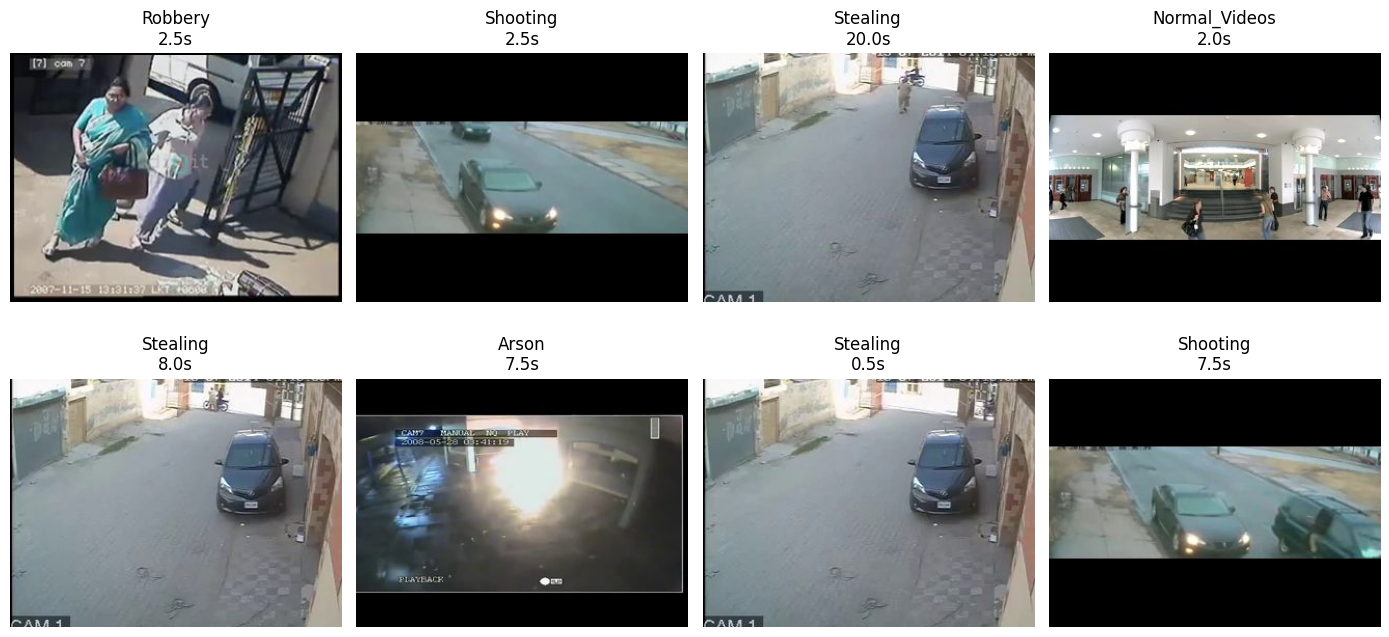

In [ ]:

banner("BRONZE | Ejemplos de frames originales")

n_show = min(8, len(bronze_frames_df))

sample_rows = bronze_frames_df.sample(
    n_show,
    random_state=42
)

fig, axes = plt.subplots(
    2,
    math.ceil(n_show / 2),
    figsize=(14, 7)
)

axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img = Image.open(row["frame_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"{row['source_category']}\n"
        f"{row['timestamp_s']:.1f}s"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

# CAPA SILVER — — Etapa 1:


- `varianza laplaciana`: nitidez ;
- `iluminacion`: iluminación media;
- `contraste`: contraste aproximado mediante desviación estándar;


In [ ]:

banner("SILVER | Auditoría de calidad sobre TODOS los frames Bronze")

quality_rows = []

for row in tqdm(
    bronze_frames_df.to_dict("records"),
    desc="Midiendo calidad"
):

    img = cv2.imread(row["frame_path"])

    if img is None:
        quality_rows.append({
            "frame_id": row["frame_id"],
            "read_ok": False,
            "laplacian_variance": np.nan,
            "brightness": np.nan,
            "contrast_std": np.nan,
        })
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    quality_rows.append({
        "frame_id": row["frame_id"],
        "read_ok": True,
        "laplacian_variance": float(
            cv2.Laplacian(gray, cv2.CV_64F).var()
        ),
        "brightness": float(gray.mean()),
        "contrast_std": float(gray.std()),
    })

quality_df = pd.DataFrame(quality_rows)

quality_audit_df = bronze_frames_df.merge(
    quality_df,
    on="frame_id",
    how="left"
)

quality_audit_df["low_sharpness"] = (
    quality_audit_df["laplacian_variance"] < BLUR_THRESHOLD
)

quality_audit_df["too_dark"] = (
    quality_audit_df["brightness"] < DARK_THRESHOLD
)

quality_audit_df["too_bright"] = (
    quality_audit_df["brightness"] > BRIGHT_THRESHOLD
)

quality_audit_df["low_contrast"] = (
    quality_audit_df["contrast_std"] < LOW_CONTRAST_THRESHOLD
)

def quality_reason(row):
    reasons = []

    if not bool(row["read_ok"]):
        reasons.append("error_lectura")

    if bool(row["low_sharpness"]):
        reasons.append("baja_nitidez")

    if bool(row["too_dark"]):
        reasons.append("oscura")

    if bool(row["too_bright"]):
        reasons.append("sobreexpuesta")

    if bool(row["low_contrast"]):
        reasons.append("bajo_contraste")

    return "|".join(reasons) if reasons else "usable"

quality_audit_df["quality_reason"] = quality_audit_df.apply(
    quality_reason,
    axis=1
)

# Regla que decide qué continúa a inferencia.
base_pass = (
    quality_audit_df["read_ok"]
    & ~quality_audit_df["low_sharpness"]
    & ~quality_audit_df["too_dark"]
    & ~quality_audit_df["too_bright"]
)

if USE_CONTRAST_IN_FILTER:
    base_pass = base_pass & ~quality_audit_df["low_contrast"]

quality_audit_df["quality_pass"] = base_pass

SILVER_QUALITY_AUDIT = SILVER_DIR / "frames_quality_audit.parquet"
save_parquet(quality_audit_df, SILVER_QUALITY_AUDIT)

print("✓ Calidad calculada para", f"{len(quality_audit_df):,}", "frames.")


SILVER | Auditoría de calidad sobre TODOS los frames Bronze


Midiendo calidad:   0%|          | 0/209 [00:00<?, ?it/s]

✓ Guardado: /content/ojoalerta_lakehouse/silver/visual/frames_quality_audit.parquet | 0.026 MB
✓ Calidad calculada para 209 frames.


In [ ]:

banner("SILVER | Conteos de calidad ANTES de excluir frames")

total = len(quality_audit_df)

quality_counts = pd.DataFrame([
    {
        "criterio": "Total Bronze auditado",
        "frames": total,
        "porcentaje": 100.0,
    },
    {
        "criterio": f"Baja nitidez (Laplaciano < {BLUR_THRESHOLD})",
        "frames": int(quality_audit_df["low_sharpness"].sum()),
        "porcentaje": 100 * quality_audit_df["low_sharpness"].mean(),
    },
    {
        "criterio": f"Oscuros (brillo < {DARK_THRESHOLD})",
        "frames": int(quality_audit_df["too_dark"].sum()),
        "porcentaje": 100 * quality_audit_df["too_dark"].mean(),
    },
    {
        "criterio": f"Sobreexpuestos (brillo > {BRIGHT_THRESHOLD})",
        "frames": int(quality_audit_df["too_bright"].sum()),
        "porcentaje": 100 * quality_audit_df["too_bright"].mean(),
    },
    {
        "criterio": f"Bajo contraste (std < {LOW_CONTRAST_THRESHOLD})",
        "frames": int(quality_audit_df["low_contrast"].sum()),
        "porcentaje": 100 * quality_audit_df["low_contrast"].mean(),
    },
    {
        "criterio": "Error de lectura",
        "frames": int((~quality_audit_df["read_ok"]).sum()),
        "porcentaje": 100 * (~quality_audit_df["read_ok"]).mean(),
    },
    {
        "criterio": "Excluidos por regla activa",
        "frames": int((~quality_audit_df["quality_pass"]).sum()),
        "porcentaje": 100 * (~quality_audit_df["quality_pass"]).mean(),
    },
    {
        "criterio": "Aceptados para Silver",
        "frames": int(quality_audit_df["quality_pass"].sum()),
        "porcentaje": 100 * quality_audit_df["quality_pass"].mean(),
    },
])

display(quality_counts.round(2))

print("\nRazones observadas")
display(
    count_table(
        quality_audit_df,
        "quality_reason",
        name="frames"
    )
)

print("\nEstadísticas numéricas")
display(
    quality_audit_df[
        [
            "laplacian_variance",
            "brightness",
            "contrast_std",
            "size_KB",
            "width",
            "height",
        ]
    ].describe().round(3)
)


SILVER | Conteos de calidad ANTES de excluir frames


,criterio,frames,porcentaje
0,Total Bronze auditado,209,100.00
1,Baja nitidez (Laplaciano < 80.0),1,0.48
2,Oscuros (brillo < 45.0),46,22.01
3,Sobreexpuestos (brillo > 210.0),0,0.00
4,Bajo contraste (std < 20.0),1,0.48
5,Error de lectura,0,0.00
6,Excluidos por regla activa,46,22.01
7,Aceptados para Silver,163,77.99



Razones observadas


,quality_reason,frames
0,usable,163
1,oscura,45
2,baja_nitidez|oscura|bajo_contraste,1



Estadísticas numéricas


,laplacian_variance,brightness,contrast_std,size_KB,width,height
count,209.000,209.000,209.000,209.000,209.0,209.0
mean,879.569,79.617,54.386,10.418,320.0,240.0
std,324.289,43.461,20.661,2.745,0.0,0.0
min,0.003,0.003,0.054,1.791,320.0,240.0
25%,721.952,59.987,39.891,7.643,320.0,240.0
50%,780.741,74.854,64.400,10.062,320.0,240.0
75%,1014.432,113.428,69.184,12.414,320.0,240.0
max,1644.359,140.148,86.402,18.854,320.0,240.0


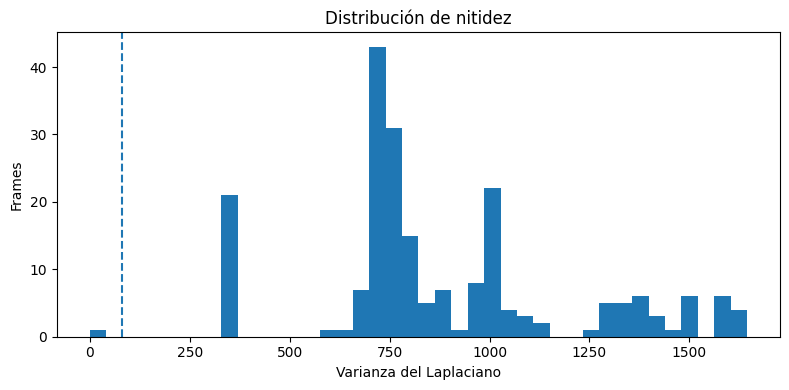

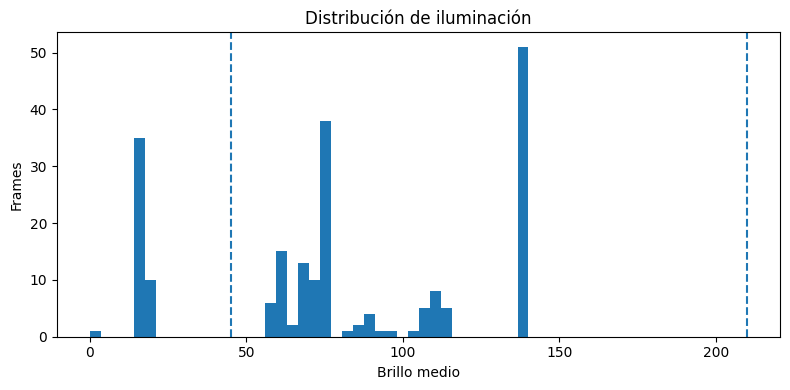

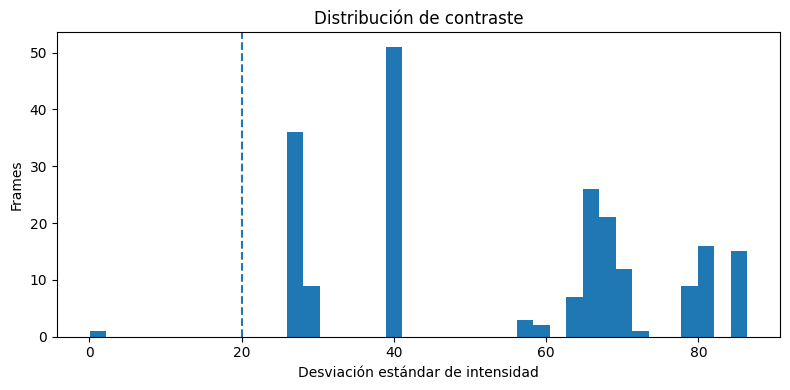

In [ ]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    quality_audit_df["laplacian_variance"].dropna(),
    bins=40
)
ax.axvline(
    BLUR_THRESHOLD,
    linestyle="--"
)
ax.set_xlabel("Varianza del Laplaciano")
ax.set_ylabel("Frames")
ax.set_title("Distribución de nitidez")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    quality_audit_df["brightness"].dropna(),
    bins=40
)
ax.axvline(
    DARK_THRESHOLD,
    linestyle="--"
)
ax.axvline(
    BRIGHT_THRESHOLD,
    linestyle="--"
)
ax.set_xlabel("Brillo medio")
ax.set_ylabel("Frames")
ax.set_title("Distribución de iluminación")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    quality_audit_df["contrast_std"].dropna(),
    bins=40
)
ax.axvline(
    LOW_CONTRAST_THRESHOLD,
    linestyle="--"
)
ax.set_xlabel("Desviación estándar de intensidad")
ax.set_ylabel("Frames")
ax.set_title("Distribución de contraste")
plt.tight_layout()
plt.show()

In [ ]:

banner("SILVER | Separación lógica de frames")

silver_frames_df = (
    quality_audit_df[
        quality_audit_df["quality_pass"]
    ]
    .copy()
    .reset_index(drop=True)
)

rejected_frames_df = (
    quality_audit_df[
        ~quality_audit_df["quality_pass"]
    ]
    .copy()
    .reset_index(drop=True)
)

SILVER_ACCEPTED = SILVER_DIR / "frames_accepted.parquet"
SILVER_REJECTED = SILVER_DIR / "frames_rejected.parquet"

save_parquet(silver_frames_df, SILVER_ACCEPTED)
save_parquet(rejected_frames_df, SILVER_REJECTED)

print("\nTRANSICIÓN BRONZE → SILVER")
print(f"Frames Bronze                  : {len(quality_audit_df):,}")
print(f"Frames excluidos de inferencia : {len(rejected_frames_df):,}")
print(f"Frames que continúan           : {len(silver_frames_df):,}")
print(
    "Retención                   : "
    f"{100*len(silver_frames_df)/len(quality_audit_df):.2f}%"
)

display(
    pd.DataFrame({
        "estado": ["Bronze", "Excluidos", "Silver aceptados"],
        "frames": [
            len(quality_audit_df),
            len(rejected_frames_df),
            len(silver_frames_df),
        ],
    })
)

register_count(
    "SILVER",
    "control_calidad",
    records_in=len(quality_audit_df),
    records_out=len(silver_frames_df),
    excluded=len(rejected_frames_df),
    note=(
        "Bronze se conserva intacto. "
        "Los rechazados solo se excluyen de la inferencia."
    ),
    path=SILVER_ACCEPTED,
)

if silver_frames_df.empty:
    raise RuntimeError(
        "Todos los frames fueron excluidos. "
        "Revisa los umbrales de calidad antes de continuar."
    )


SILVER | Separación lógica de frames
✓ Guardado: /content/ojoalerta_lakehouse/silver/visual/frames_accepted.parquet | 0.023 MB
✓ Guardado: /content/ojoalerta_lakehouse/silver/visual/frames_rejected.parquet | 0.016 MB

TRANSICIÓN BRONZE → SILVER
Frames Bronze                  : 209
Frames excluidos de inferencia : 46
Frames que continúan           : 163
Retención                   : 77.99%


,estado,frames
0,Bronze,209
1,Excluidos,46
2,Silver aceptados,163



SILVER | Ejemplos de frames excluidos


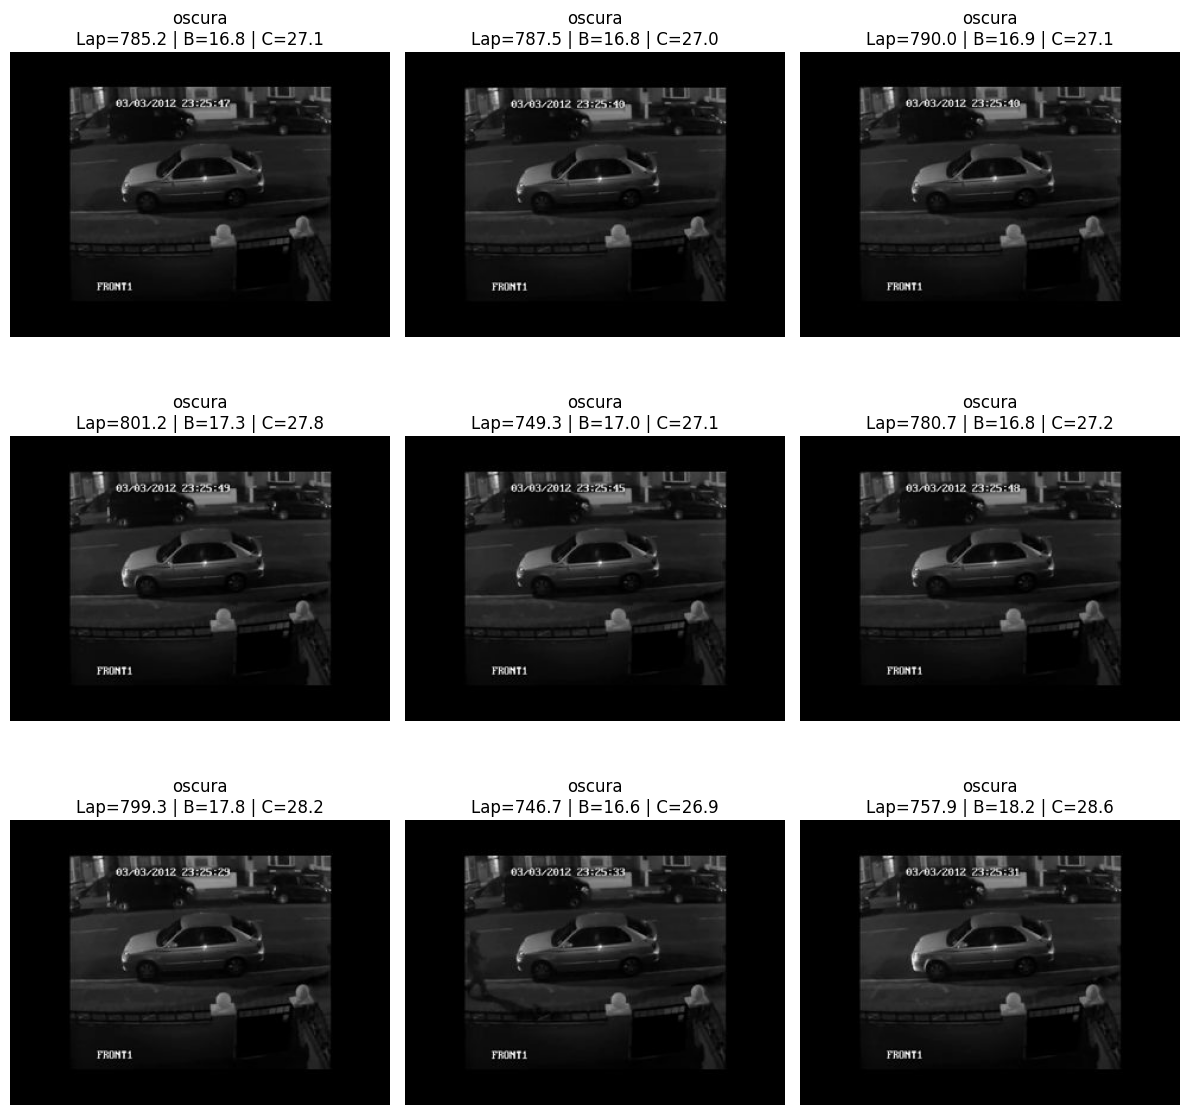

In [ ]:

banner("SILVER | Ejemplos de frames excluidos")

if rejected_frames_df.empty:
    print("No hubo frames excluidos.")
else:
    n_show = min(9, len(rejected_frames_df))

    examples = rejected_frames_df.sample(
        n_show,
        random_state=42
    )

    cols = 3
    rows = math.ceil(n_show / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(12, 4 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, examples.iterrows()):
        img = Image.open(row["frame_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"{row['quality_reason']}\n"
            f"Lap={row['laplacian_variance']:.1f} | "
            f"B={row['brightness']:.1f} | "
            f"C={row['contrast_std']:.1f}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# CAPA SILVER — Etapa 2:
Únicamente los frames que superaron el control de calidad continúan.

- **YOLO11n:** detecta objetos. No determina delitos.
- **CLIP:** compara la representación visual del frame con descripciones semánticas de la taxonomía.
- Si CLIP no alcanza el score y margen mínimos, el frame queda como **indeterminado**.

No hay tracking ni generación de tracklets en este notebook.

In [ ]:
# CELDA 13 — SILVER: TAXONOMÍA VISUAL

banner("SILVER | Taxonomía utilizada por la rama visual")

taxonomy = pd.DataFrame([
    ["T01", "agresion"],
    ["T02", "robo"],
    ["T03", "sustraccion"],
    ["T04", "vandalismo"],
    ["T05", "incendio"],
    ["T06", "disparos"],
    ["T07", "accidente_vial"],
    ["T08", "explosion"],
    ["T09", "intervencion_policial"],
    ["T10", "normal"],
    ["TX",  "indeterminado"],
], columns=["taxonomy_id", "taxonomy_label"])

UCF_TO_TAXONOMY = {
    "Abuse": "T01",
    "Assault": "T01",
    "Fighting": "T01",
    "Robbery": "T02",
    "Burglary": "T02",
    "Stealing": "T03",
    "Shoplifting": "T03",
    "Vandalism": "T04",
    "Arson": "T05",
    "Shooting": "T06",
    "RoadAccidents": "T07",
    "Explosion": "T08",
    "Arrest": "T09",
    "Normal_Videos": "T10",
}

taxonomy_map = dict(
    zip(
        taxonomy["taxonomy_id"],
        taxonomy["taxonomy_label"]
    )
)

display(taxonomy)

TAXONOMY_PATH = SILVER_DIR / "visual_taxonomy.parquet"
save_parquet(taxonomy, TAXONOMY_PATH)


SILVER | Taxonomía utilizada por la rama visual


,taxonomy_id,taxonomy_label
0,T01,agresion
1,T02,robo
2,T03,sustraccion
3,T04,vandalismo
4,T05,incendio
5,T06,disparos
6,T07,accidente_vial
7,T08,explosion
8,T09,intervencion_policial
9,T10,normal


✓ Guardado: /content/ojoalerta_lakehouse/silver/visual/visual_taxonomy.parquet | 0.002 MB


In [ ]:

banner("SILVER | YOLO11n")

yolo = YOLO("yolo11n.pt")

frames_to_process = (
    silver_frames_df
    .iloc[::INFERENCE_STRIDE]
    .copy()
    .reset_index(drop=True)
)

print(f"Frames Bronze                  : {len(bronze_frames_df):,}")
print(f"Frames Silver tras calidad     : {len(silver_frames_df):,}")
print(f"Frames enviados a inferencia   : {len(frames_to_process):,}")
print(f"Confianza mínima YOLO          : {YOLO_CONF}")
print(f"Tamaño de entrada YOLO         : {YOLO_IMGSZ}")


SILVER | YOLO11n
Frames Bronze                  : 209
Frames Silver tras calidad     : 163
Frames enviados a inferencia   : 163
Confianza mínima YOLO          : 0.25
Tamaño de entrada YOLO         : 640


In [ ]:

banner("SILVER | Detección de objetos")

yolo_records = []

paths = frames_to_process["frame_path"].tolist()
frame_ids = frames_to_process["frame_id"].tolist()

for start in tqdm(
    range(0, len(paths), YOLO_BATCH),
    desc="YOLO"
):
    batch_paths = paths[start:start + YOLO_BATCH]
    batch_ids = frame_ids[start:start + YOLO_BATCH]

    results = yolo.predict(
        source=batch_paths,
        imgsz=YOLO_IMGSZ,
        conf=YOLO_CONF,
        device=0 if DEVICE == "cuda" else "cpu",
        verbose=False,
    )

    for frame_id, result in zip(batch_ids, results):

        detected = []

        if result.boxes is not None and len(result.boxes) > 0:

            classes = (
                result.boxes.cls.detach()
                .cpu().numpy()
            )

            confidences = (
                result.boxes.conf.detach()
                .cpu().numpy()
            )

            for cls_id, conf in zip(classes, confidences):
                detected.append({
                    "class": result.names[int(cls_id)],
                    "confidence": round(float(conf), 6),
                })

        yolo_records.append({
            "frame_id": frame_id,
            "yolo_objects": detected,
            "object_count": len(detected),
            "yolo_status": (
                "con_detecciones"
                if len(detected) > 0
                else "sin_detecciones_confiables"
            ),
        })

yolo_df = pd.DataFrame(yolo_records)

yolo_df["yolo_objects_json"] = (
    yolo_df["yolo_objects"]
    .apply(
        lambda x: json.dumps(
            x,
            ensure_ascii=False
        )
    )
)

YOLO_OUTPUT = SILVER_DIR / "yolo_detections.parquet"
save_parquet(
    yolo_df.drop(columns=["yolo_objects"]),
    YOLO_OUTPUT
)

display(
    count_table(
        yolo_df,
        "yolo_status",
        "frames"
    )
)

objects = [
    item["class"]
    for items in yolo_df["yolo_objects"]
    for item in items
]

if objects:
    print("\nObjetos más frecuentes")
    display(
        pd.Series(objects)
        .value_counts()
        .head(20)
        .rename_axis("objeto")
        .reset_index(name="detecciones")
    )

register_count(
    "SILVER",
    "yolo",
    records_in=len(frames_to_process),
    records_out=len(yolo_df),
    excluded=int((yolo_df["object_count"] == 0).sum()),
    note="Sin detección no equivale a ausencia de incidente",
    path=YOLO_OUTPUT,
)


SILVER | Detección de objetos


YOLO:   0%|          | 0/6 [00:00<?, ?it/s]

✓ Guardado: /content/ojoalerta_lakehouse/silver/visual/yolo_detections.parquet | 0.009 MB


,yolo_status,frames
0,con_detecciones,147
1,sin_detecciones_confiables,16



Objetos más frecuentes


,objeto,detecciones
0,person,220
1,car,155
2,motorcycle,33
3,truck,26
4,bus,26
5,bicycle,13
6,dog,8
7,handbag,3
8,backpack,1


In [ ]:

banner("SILVER | CLIP")

clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_NAME
).to(DEVICE)

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME
)

clip_model.eval()

TAXONOMY_PROMPTS = {
    "T01": [
        "a surveillance image of a physical assault",
        "people physically fighting in a public place",
        "one person attacking another person",
    ],
    "T02": [
        "a surveillance image of a robbery",
        "a person being robbed by force or threat",
        "someone taking property from another person by force",
    ],
    "T03": [
        "a surveillance image of someone stealing an object",
        "a person taking another person's belongings",
        "a theft captured by a surveillance camera",
    ],
    "T04": [
        "a surveillance image of vandalism",
        "a person intentionally damaging property",
        "intentional damage to public or private property",
    ],
    "T05": [
        "a surveillance image of arson",
        "intentional fire in a public or private place",
        "a person intentionally setting property on fire",
    ],
    "T06": [
        "a surveillance image involving a shooting",
        "a firearm being used against a person",
        "a shooting incident captured by surveillance camera",
    ],
    "T07": [
        "a surveillance image of a road traffic accident",
        "vehicles involved in a traffic collision",
        "a traffic crash captured by surveillance camera",
    ],
    "T08": [
        "a surveillance image of an explosion",
        "an explosion occurring in a public place",
        "a blast captured by surveillance camera",
    ],
    "T09": [
        "a surveillance image of a police arrest",
        "police officers arresting a person",
        "a person being detained by police",
    ],
    "T10": [
        "a normal surveillance scene with no security incident",
        "people behaving normally in a public place",
        "an ordinary surveillance image with no visible incident",
    ],
}

category_ids = list(TAXONOMY_PROMPTS.keys())

for tax_id, prompts in TAXONOMY_PROMPTS.items():
    print(
        f"{tax_id} — {taxonomy_map[tax_id]}: "
        f"{len(prompts)} prompts"
    )


SILVER | CLIP


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

T01 — agresion: 3 prompts
T02 — robo: 3 prompts
T03 — sustraccion: 3 prompts
T04 — vandalismo: 3 prompts
T05 — incendio: 3 prompts
T06 — disparos: 3 prompts
T07 — accidente_vial: 3 prompts
T08 — explosion: 3 prompts
T09 — intervencion_policial: 3 prompts
T10 — normal: 3 prompts


In [ ]:

banner("SILVER | Codificación de referencias textuales")

category_text_features = []

with torch.no_grad():

    for tax_id in tqdm(
        category_ids,
        desc="Prompts por categoría"
    ):

        prompts = TAXONOMY_PROMPTS[tax_id]

        text_inputs = clip_processor(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )

        text_inputs = {
            k: v.to(DEVICE)
            for k, v in text_inputs.items()
        }

        text_outputs = clip_model.text_model(
            input_ids=text_inputs["input_ids"],
            attention_mask=text_inputs.get("attention_mask"),
        )

        pooled_text = text_outputs.pooler_output
        prompt_features = clip_model.text_projection(pooled_text)
        prompt_features = F.normalize(
            prompt_features,
            p=2,
            dim=-1
        )

        cat_feature = prompt_features.mean(
            dim=0,
            keepdim=True
        )

        cat_feature = F.normalize(
            cat_feature,
            p=2,
            dim=-1
        )

        category_text_features.append(cat_feature)

text_features = torch.cat(
    category_text_features,
    dim=0
)

print("Embeddings por categoría:", tuple(text_features.shape))
print("Orden:", category_ids)


SILVER | Codificación de referencias textuales


Prompts por categoría:   0%|          | 0/10 [00:00<?, ?it/s]

Embeddings por categoría: (10, 512)
Orden: ['T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08', 'T09', 'T10']


In [ ]:

banner("SILVER | Clasificación semántica por frame")

clip_records = []

paths = frames_to_process["frame_path"].tolist()
ids = frames_to_process["frame_id"].tolist()

logit_scale = (
    clip_model.logit_scale
    .exp()
    .clamp(max=100)
    .detach()
)

for start in tqdm(
    range(0, len(paths), CLIP_BATCH),
    desc="CLIP"
):

    batch_paths = paths[start:start + CLIP_BATCH]
    batch_ids = ids[start:start + CLIP_BATCH]

    images = [
        Image.open(p).convert("RGB")
        for p in batch_paths
    ]

    inputs = clip_processor(
        images=images,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(DEVICE)

    with torch.no_grad():

        vision_outputs = clip_model.vision_model(
            pixel_values=pixel_values
        )

        pooled_image = vision_outputs.pooler_output

        image_features = clip_model.visual_projection(
            pooled_image
        )

        image_features = F.normalize(
            image_features,
            p=2,
            dim=-1
        )

        similarities = image_features @ text_features.T

        probs = (
            logit_scale * similarities
        ).softmax(dim=-1)

    top2_scores, top2_idx = probs.topk(
        k=2,
        dim=-1
    )

    probs_np = probs.detach().cpu().numpy()
    top2_scores_np = top2_scores.detach().cpu().numpy()
    top2_idx_np = top2_idx.detach().cpu().numpy()

    for row_pos, frame_id in enumerate(batch_ids):

        best_idx = int(
            top2_idx_np[row_pos, 0]
        )

        second_idx = int(
            top2_idx_np[row_pos, 1]
        )

        top1_score = float(
            top2_scores_np[row_pos, 0]
        )

        top2_score = float(
            top2_scores_np[row_pos, 1]
        )

        margin = top1_score - top2_score

        raw_tax_id = category_ids[best_idx]
        second_tax_id = category_ids[second_idx]

        conclusive = (
            top1_score >= CLIP_MIN_SCORE
            and margin >= CLIP_MIN_MARGIN
        )

        final_tax_id = (
            raw_tax_id
            if conclusive
            else "TX"
        )

        score_dict = {
            category_ids[j]: float(
                probs_np[row_pos, j]
            )
            for j in range(len(category_ids))
        }

        record = {
            "frame_id": frame_id,
            "clip_raw_taxonomy_id": raw_tax_id,
            "clip_second_taxonomy_id": second_tax_id,
            "clip_top1_score": top1_score,
            "clip_top2_score": top2_score,
            "clip_margin": margin,
            "clip_status": (
                "concluyente"
                if conclusive
                else "indeterminado"
            ),
            "visual_taxonomy_id": final_tax_id,
            "visual_score": top1_score,
            "clip_scores_json": json.dumps(
                score_dict,
                ensure_ascii=False
            ),
        }

        for tax_id, value in score_dict.items():
            record[f"clip_score_{tax_id}"] = value

        clip_records.append(record)

clip_df = pd.DataFrame(clip_records)

clip_df["visual_taxonomy_label"] = (
    clip_df["visual_taxonomy_id"]
    .map(taxonomy_map)
)

CLIP_OUTPUT = SILVER_DIR / "clip_predictions.parquet"
save_parquet(clip_df, CLIP_OUTPUT)

print("\nEstados CLIP")
display(
    count_table(
        clip_df,
        "clip_status",
        "frames"
    )
)

print("\nCategorías resultantes")
display(
    count_table(
        clip_df,
        "visual_taxonomy_label",
        "frames"
    )
)

register_count(
    "SILVER",
    "clip",
    records_in=len(frames_to_process),
    records_out=len(clip_df),
    excluded=int(
        (clip_df["clip_status"] == "indeterminado").sum()
    ),
    note="Indeterminado = evidencia semántica insuficiente/ambigua",
    path=CLIP_OUTPUT,
)


SILVER | Clasificación semántica por frame


CLIP:   0%|          | 0/6 [00:00<?, ?it/s]

✓ Guardado: /content/ojoalerta_lakehouse/silver/visual/clip_predictions.parquet | 0.058 MB

Estados CLIP


,clip_status,frames
0,concluyente,115
1,indeterminado,48



Categorías resultantes


,visual_taxonomy_label,frames
0,sustraccion,54
1,indeterminado,48
2,disparos,16
3,normal,12
4,accidente_vial,12
5,incendio,9
6,agresion,6
7,explosion,5
8,vandalismo,1


In [ ]:

banner("SILVER | Tabla final por frame")

visual_silver_df = (
    frames_to_process
    .merge(
        yolo_df[
            [
                "frame_id",
                "yolo_objects_json",
                "object_count",
                "yolo_status",
            ]
        ],
        on="frame_id",
        how="left",
    )
    .merge(
        clip_df,
        on="frame_id",
        how="left",
    )
)

visual_silver_df["source_taxonomy_id"] = (
    visual_silver_df["source_category"]
    .map(UCF_TO_TAXONOMY)
)

visual_silver_df["source_taxonomy_label"] = (
    visual_silver_df["source_taxonomy_id"]
    .map(taxonomy_map)
)

SILVER_FEATURES = SILVER_DIR / "visual_frame_features.parquet"
save_parquet(
    visual_silver_df,
    SILVER_FEATURES
)

print(f"Registros Silver finales: {len(visual_silver_df):,}")

display(
    visual_silver_df[
        [
            "frame_id",
            "video_id",
            "timestamp_s",
            "laplacian_variance",
            "brightness",
            "contrast_std",
            "object_count",
            "yolo_status",
            "visual_taxonomy_label",
            "visual_score",
            "clip_margin",
            "clip_status",
            "source_taxonomy_label",
        ]
    ].head(20)
)

register_count(
    "SILVER",
    "visual_frame_features",
    records_in=len(frames_to_process),
    records_out=len(visual_silver_df),
    excluded=0,
    note="Tabla enriquecida por frame para agregación",
    path=SILVER_FEATURES,
)


SILVER | Tabla final por frame
✓ Guardado: /content/ojoalerta_lakehouse/silver/visual/visual_frame_features.parquet | 0.087 MB
Registros Silver finales: 163


,frame_id,video_id,timestamp_s,laplacian_variance,brightness,contrast_std,object_count,yolo_status,visual_taxonomy_label,visual_score,clip_margin,clip_status,source_taxonomy_label
0,0,Assault018_x264,0.0,876.609974,76.014870,80.171136,5,con_detecciones,indeterminado,0.176892,0.009961,indeterminado,agresion
1,1,Assault018_x264,0.5,953.240625,75.559128,80.361225,5,con_detecciones,indeterminado,0.243336,0.053266,indeterminado,agresion
2,2,Assault018_x264,1.0,960.091615,74.994310,80.051567,6,con_detecciones,indeterminado,0.217344,0.032252,indeterminado,agresion
3,3,Assault018_x264,1.5,964.072813,74.334922,79.582875,5,con_detecciones,indeterminado,0.227119,0.030979,indeterminado,agresion
4,4,Assault018_x264,2.0,959.576250,73.559648,78.970560,4,con_detecciones,indeterminado,0.285684,0.074888,indeterminado,agresion
5,5,Assault018_x264,2.5,985.450964,72.402604,78.611408,5,con_detecciones,agresion,0.560013,0.366692,concluyente,agresion
6,6,Assault018_x264,3.0,1001.952422,72.914219,78.937741,5,con_detecciones,agresion,0.439855,0.256503,concluyente,agresion
7,7,Assault018_x264,3.5,1012.524922,73.415872,79.332349,5,con_detecciones,agresion,0.361929,0.154480,concluyente,agresion
8,8,Assault018_x264,4.0,1015.436016,73.821576,79.562571,5,con_detecciones,indeterminado,0.295456,0.092242,indeterminado,agresion
9,9,Assault018_x264,4.5,1017.476875,74.050807,79.764928,4,con_detecciones,agresion,0.397141,0.206763,concluyente,agresion


# CAPA GOLD



- segmentos temporales de 5 segundos;
- predicción agregada por video;
- métricas de evaluación a nivel de video;

No se realiza integración con el CSV textual.

In [ ]:

banner("GOLD | Segmentos temporales")

visual_silver_df["segment_id"] = (
    visual_silver_df["timestamp_s"]
    // SEGMENT_SECONDS
).astype(int)

def mode_non_null(series):
    mode = series.dropna().mode()
    return None if len(mode) == 0 else mode.iloc[0]

segments_df = (
    visual_silver_df
    .groupby(
        [
            "video_id",
            "source_category",
            "segment_id",
        ],
        as_index=False
    )
    .agg(
        start_time=("timestamp_s", "min"),
        end_time=("timestamp_s", "max"),
        frames=("frame_id", "count"),
        objetos_promedio=("object_count", "mean"),
        clip_predominante=(
            "visual_taxonomy_label",
            mode_non_null
        ),
        clip_score_promedio=(
            "visual_score",
            "mean"
        ),
        frames_indeterminados=(
            "clip_status",
            lambda s: int(
                (s == "indeterminado").sum()
            )
        ),
    )
)

GOLD_SEGMENTS = GOLD_DIR / "visual_segments.parquet"
save_parquet(segments_df, GOLD_SEGMENTS)

print("Segmentos Gold:", len(segments_df))
display(segments_df.head(20))

register_count(
    "GOLD",
    "segmentos_5s",
    records_in=len(visual_silver_df),
    records_out=len(segments_df),
    excluded=None,
    note=f"Agregación cada {SEGMENT_SECONDS} segundos",
    path=GOLD_SEGMENTS,
)


GOLD | Segmentos temporales
✓ Guardado: /content/ojoalerta_lakehouse/gold/visual/visual_segments.parquet | 0.007 MB
Segmentos Gold: 20


,video_id,source_category,segment_id,start_time,end_time,frames,objetos_promedio,clip_predominante,clip_score_promedio,frames_indeterminados
0,Arson049_x264,Arson,0,0.0,4.5,10,0.500000,indeterminado,0.329370,5
1,Arson049_x264,Arson,1,5.0,9.5,10,0.400000,incendio,0.558792,2
2,Arson049_x264,Arson,2,10.0,12.5,6,0.166667,explosion,0.535455,2
3,Assault018_x264,Assault,0,0.0,4.5,10,4.900000,indeterminado,0.320477,6
4,Assault018_x264,Assault,1,5.0,9.5,10,3.500000,indeterminado,0.241140,9
5,Assault018_x264,Assault,2,10.0,11.5,4,3.250000,indeterminado,0.244003,4
6,Normal_Videos_881_x264,Normal_Videos,0,0.0,4.5,10,8.000000,normal,0.367284,1
7,Normal_Videos_881_x264,Normal_Videos,1,5.0,7.0,5,8.600000,normal,0.322047,2
8,RoadAccidents027_x264,RoadAccidents,0,0.0,3.0,7,7.428571,accidente_vial,0.581995,0
9,Robbery089_x264,Robbery,0,0.0,4.5,10,3.200000,sustraccion,0.450701,1


In [ ]:

banner("GOLD | Predicción por video")

score_cols = [
    f"clip_score_{tax_id}"
    for tax_id in category_ids
]

video_score_df = (
    visual_silver_df
    .groupby(
        ["video_id", "source_category"],
        as_index=False
    )
    .agg(
        frames=("frame_id", "count"),
        frames_concluyentes=(
            "clip_status",
            lambda s: int(
                (s == "concluyente").sum()
            )
        ),
        **{
            col: (col, "mean")
            for col in score_cols
        }
    )
)

video_predictions = []

for row in video_score_df.to_dict("records"):

    scores = {
        tax_id: float(
            row[f"clip_score_{tax_id}"]
        )
        for tax_id in category_ids
    }

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    raw_id, top_score = ranked[0]
    second_id, second_score = ranked[1]
    margin = top_score - second_score

    conclusive_share = (
        row["frames_concluyentes"]
        / row["frames"]
        if row["frames"]
        else 0
    )

    conclusive = (
        top_score >= VIDEO_MIN_SCORE
        and margin >= VIDEO_MIN_MARGIN
        and conclusive_share
            >= VIDEO_MIN_CONCLUSIVE_SHARE
    )

    pred_id = (
        raw_id
        if conclusive
        else "TX"
    )

    source_tax_id = UCF_TO_TAXONOMY.get(
        row["source_category"]
    )

    video_predictions.append({
        "video_id": row["video_id"],
        "source_category": row["source_category"],
        "source_taxonomy_id": source_tax_id,
        "source_taxonomy_label": taxonomy_map.get(
            source_tax_id
        ),
        "video_raw_prediction_id": raw_id,
        "video_raw_prediction_label": taxonomy_map.get(
            raw_id
        ),
        "video_prediction_id": pred_id,
        "video_prediction_label": taxonomy_map.get(
            pred_id
        ),
        "video_top_score": top_score,
        "video_second_score": second_score,
        "video_margin": margin,
        "frames": row["frames"],
        "frames_concluyentes": row["frames_concluyentes"],
        "conclusive_share": conclusive_share,
        "video_status": (
            "concluyente"
            if conclusive
            else "indeterminado"
        ),
        "acierto": (
            pred_id == source_tax_id
            if pred_id != "TX"
            and source_tax_id is not None
            else False
        ),
    })

video_eval_df = pd.DataFrame(
    video_predictions
)

GOLD_VIDEO = GOLD_DIR / "video_predictions.parquet"
save_parquet(
    video_eval_df,
    GOLD_VIDEO
)

display(
    video_eval_df[
        [
            "video_id",
            "source_category",
            "source_taxonomy_label",
            "video_prediction_label",
            "video_top_score",
            "video_margin",
            "conclusive_share",
            "video_status",
            "acierto",
        ]
    ].round(4)
)

register_count(
    "GOLD",
    "predicciones_video",
    records_in=len(visual_silver_df),
    records_out=len(video_eval_df),
    excluded=int(
        (video_eval_df["video_status"] == "indeterminado").sum()
    ),
    note="Referencia UCF-Crime utilizada únicamente a nivel de video",
    path=GOLD_VIDEO,
)


GOLD | Predicción por video
✓ Guardado: /content/ojoalerta_lakehouse/gold/visual/video_predictions.parquet | 0.011 MB


,video_id,source_category,source_taxonomy_label,video_prediction_label,video_top_score,video_margin,conclusive_share,video_status,acierto
0,Arson049_x264,Arson,incendio,indeterminado,0.3752,0.0054,0.6538,indeterminado,False
1,Assault018_x264,Assault,agresion,agresion,0.2697,0.0713,0.2083,concluyente,True
2,Normal_Videos_881_x264,Normal_Videos,normal,normal,0.3522,0.1713,0.8000,concluyente,True
3,RoadAccidents027_x264,RoadAccidents,accidente_vial,accidente_vial,0.5820,0.4217,1.0000,concluyente,True
4,Robbery089_x264,Robbery,robo,sustraccion,0.3253,0.1301,0.8947,concluyente,False
5,Shooting037_x264,Shooting,disparos,indeterminado,0.2640,0.0073,0.5238,indeterminado,False
6,Stealing095_x264,Stealing,sustraccion,sustraccion,0.3670,0.1777,0.9020,concluyente,True



GOLD | Métricas de evaluación


,videos_evaluados,coverage_concluyente,accuracy,precision_macro,recall_macro,f1_macro
0,7,0.7143,0.5714,0.4375,0.5,0.4583


                precision    recall  f1-score   support

accidente_vial     1.0000    1.0000    1.0000         1
      agresion     1.0000    1.0000    1.0000         1
      disparos     0.0000    0.0000    0.0000         1
      incendio     0.0000    0.0000    0.0000         1
 indeterminado     0.0000    0.0000    0.0000         0
        normal     1.0000    1.0000    1.0000         1
          robo     0.0000    0.0000    0.0000         1
   sustraccion     0.5000    1.0000    0.6667         1

      accuracy                         0.5714         7
     macro avg     0.4375    0.5000    0.4583         7
  weighted avg     0.5000    0.5714    0.5238         7



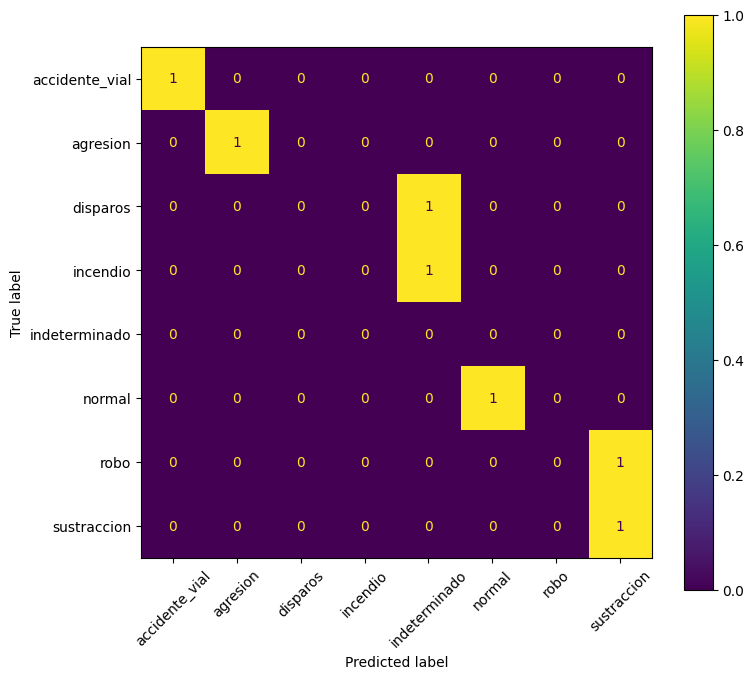

✓ Métricas: /content/ojoalerta_lakehouse/gold/visual/visual_metrics.csv

Nota: no se calcula mAP de YOLO porque este experimento no dispone de bounding boxes ground-truth por frame.


In [ ]:

banner("GOLD | Métricas de evaluación")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

eval_all = video_eval_df.dropna(
    subset=[
        "source_taxonomy_label",
        "video_prediction_label",
    ]
).copy()

coverage = (
    (eval_all["video_status"] == "concluyente").mean()
    if len(eval_all)
    else np.nan
)

accuracy_all = (
    accuracy_score(
        eval_all["source_taxonomy_label"],
        eval_all["video_prediction_label"],
    )
    if len(eval_all)
    else np.nan
)

precision_macro = (
    precision_score(
        eval_all["source_taxonomy_label"],
        eval_all["video_prediction_label"],
        average="macro",
        zero_division=0,
    )
    if len(eval_all)
    else np.nan
)

recall_macro = (
    recall_score(
        eval_all["source_taxonomy_label"],
        eval_all["video_prediction_label"],
        average="macro",
        zero_division=0,
    )
    if len(eval_all)
    else np.nan
)

f1_macro = (
    f1_score(
        eval_all["source_taxonomy_label"],
        eval_all["video_prediction_label"],
        average="macro",
        zero_division=0,
    )
    if len(eval_all)
    else np.nan
)

metrics_df = pd.DataFrame([
    {
        "videos_evaluados": len(eval_all),
        "coverage_concluyente": coverage,
        "accuracy": accuracy_all,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
    }
])

display(metrics_df.round(4))

if len(eval_all):

    print(
        classification_report(
            eval_all["source_taxonomy_label"],
            eval_all["video_prediction_label"],
            digits=4,
            zero_division=0,
        )
    )

    fig, ax = plt.subplots(
        figsize=(8, 7)
    )

    ConfusionMatrixDisplay.from_predictions(
        eval_all["source_taxonomy_label"],
        eval_all["video_prediction_label"],
        xticks_rotation=45,
        ax=ax,
    )

    plt.tight_layout()
    plt.show()

GOLD_METRICS = GOLD_DIR / "visual_metrics.csv"
metrics_df.to_csv(
    GOLD_METRICS,
    index=False
)

print("✓ Métricas:", GOLD_METRICS)
print(
    "\nNota: no se calcula mAP de YOLO porque este experimento "
    "no dispone de bounding boxes ground-truth por frame."
)

In [ ]:

banner("RESUMEN | Bronze → Silver → Gold")

layers_df = show_layer_counts()

LAYERS_SUMMARY = LAKEHOUSE / "visual_medallion_counts.csv"
layers_df.to_csv(
    LAYERS_SUMMARY,
    index=False
)

print("\nCONTEOS PRINCIPALES")
summary_counts = pd.DataFrame([
    {
        "etapa": "Bronze - videos",
        "registros": len(videos_df)
    },
    {
        "etapa": "Bronze - frames extraídos",
        "registros": len(bronze_frames_df)
    },
    {
        "etapa": "Silver - auditados",
        "registros": len(quality_audit_df)
    },
    {
        "etapa": "Silver - rechazados por calidad",
        "registros": len(rejected_frames_df)
    },
    {
        "etapa": "Silver - aceptados",
        "registros": len(silver_frames_df)
    },
    {
        "etapa": "Silver - features por frame",
        "registros": len(visual_silver_df)
    },
    {
        "etapa": "Gold - segmentos",
        "registros": len(segments_df)
    },
    {
        "etapa": "Gold - videos",
        "registros": len(video_eval_df)
    },
])

display(summary_counts)

print("\nArchivo de trazabilidad:")
print(LAYERS_SUMMARY)


RESUMEN | Bronze → Silver → Gold


,layer,dataset,records_in,records_out,excluded_or_flagged,note,path
0,BRONZE,videos_descargados,8,8,0.0,1 video pequeño por categoría disponible,/content/ojoalerta_lakehouse/bronze/visual/vid...
1,BRONZE,frames_extraidos,3077,209,NaN,Extracción a 2 FPS; todavía sin filtro de calidad,/content/ojoalerta_lakehouse/bronze/visual/fra...
2,SILVER,control_calidad,209,163,46.0,Bronze se conserva intacto. Los rechazados sol...,/content/ojoalerta_lakehouse/silver/visual/fra...
3,SILVER,yolo,163,163,16.0,Sin detección no equivale a ausencia de incidente,/content/ojoalerta_lakehouse/silver/visual/yol...
4,SILVER,clip,163,163,48.0,Indeterminado = evidencia semántica insuficien...,/content/ojoalerta_lakehouse/silver/visual/cli...
5,SILVER,visual_frame_features,163,163,0.0,Tabla enriquecida por frame para agregación,/content/ojoalerta_lakehouse/silver/visual/vis...
6,GOLD,segmentos_5s,163,20,NaN,Agregación cada 5 segundos,/content/ojoalerta_lakehouse/gold/visual/visua...
7,GOLD,predicciones_video,163,7,2.0,Referencia UCF-Crime utilizada únicamente a ni...,/content/ojoalerta_lakehouse/gold/visual/video...



CONTEOS PRINCIPALES


,etapa,registros
0,Bronze - videos,8
1,Bronze - frames extraídos,209
2,Silver - auditados,209
3,Silver - rechazados por calidad,46
4,Silver - aceptados,163
5,Silver - features por frame,163
6,Gold - segmentos,20
7,Gold - videos,7



Archivo de trazabilidad:
/content/ojoalerta_lakehouse/visual_medallion_counts.csv


In [ ]:

banner("PANEL FINAL")

print("BRONZE")
print("  Videos           :", len(videos_df))
print("  Frames           :", len(bronze_frames_df))

print("\nSILVER")
print("  Auditados        :", len(quality_audit_df))
print("  Rechazados       :", len(rejected_frames_df))
print("  Aceptados        :", len(silver_frames_df))
print("  Features/frame   :", len(visual_silver_df))

print("\nGOLD")
print("  Segmentos        :", len(segments_df))
print("  Videos           :", len(video_eval_df))

print("\nMétricas")
display(metrics_df.round(4))

print("\nConteos por capa")
display(summary_counts)

print("\nLakehouse:")
print(LAKEHOUSE)

print(
    "\n✓ Pipeline visual finalizado. "
    "No se realizó integración con la fuente textual."
)


PANEL FINAL
BRONZE
  Videos           : 8
  Frames           : 209

SILVER
  Auditados        : 209
  Rechazados       : 46
  Aceptados        : 163
  Features/frame   : 163

GOLD
  Segmentos        : 20
  Videos           : 7

Métricas


,videos_evaluados,coverage_concluyente,accuracy,precision_macro,recall_macro,f1_macro
0,7,0.7143,0.5714,0.4375,0.5,0.4583



Conteos por capa


,etapa,registros
0,Bronze - videos,8
1,Bronze - frames extraídos,209
2,Silver - auditados,209
3,Silver - rechazados por calidad,46
4,Silver - aceptados,163
5,Silver - features por frame,163
6,Gold - segmentos,20
7,Gold - videos,7



Lakehouse:
/content/ojoalerta_lakehouse

✓ Pipeline visual finalizado. No se realizó integración con la fuente textual.
